In [1]:
import pandas as pd
df = pd.read_csv('../data/raw/customer_churn.csv')

print(df.shape)
df.head()

(900, 10)


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [3]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'])

df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
0    0.833333
1    0.166667
Name: proportion, dtype: float64

In [4]:
df.groupby('Churn')[['Total_Purchase','Years','Num_Sites','Account_Manager']].mean()

,Total_Purchase,Years,Num_Sites,Account_Manager
Churn,,,,
0,10036.952853,5.151067,8.173333,0.465333
1,10192.179933,5.883600,10.660000,0.560000


<function matplotlib.pyplot.show(close=None, block=None)>

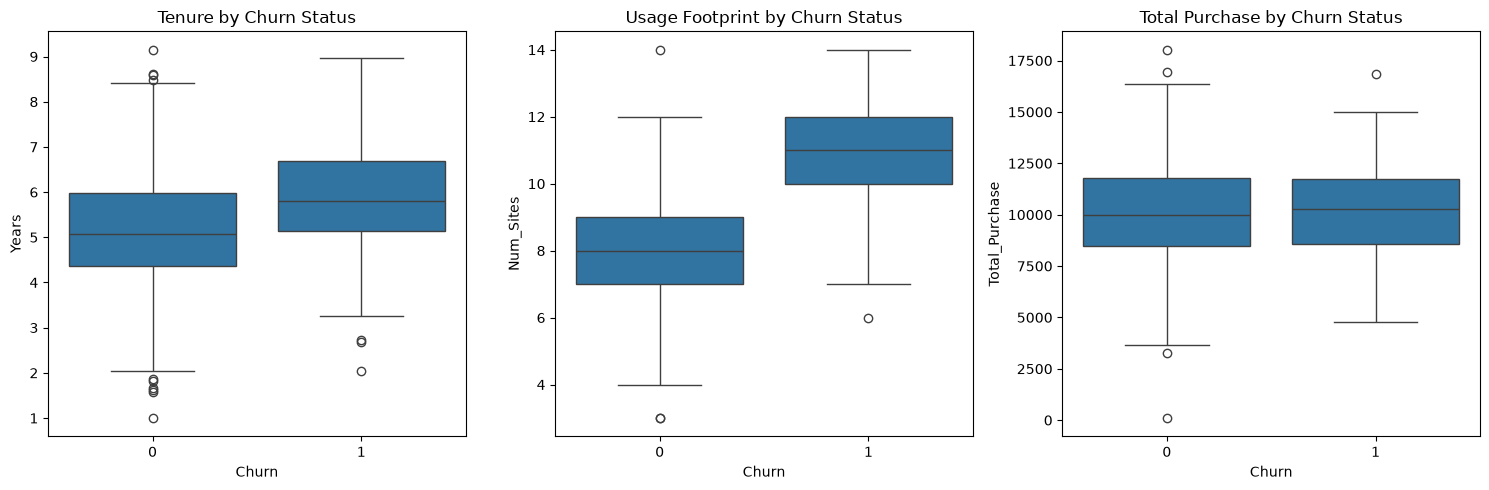

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(data=df, x='Churn', y='Years', ax=axes[0])
axes[0].set_title('Tenure by Churn Status')

sns.boxplot(data=df, x='Churn', y='Num_Sites', ax=axes[1])
axes[1].set_title('Usage Footprint by Churn Status')

sns.boxplot(data=df, x='Churn', y='Total_Purchase', ax=axes[2])
axes[2].set_title('Total Purchase by Churn Status')

plt.tight_layout()
plt.show

In [6]:
from scipy import stats

churned = df[df['Churn'] == 1]
retained = df[df['Churn'] == 0]

for col in ['Years','Num_Sites']:
    t_stat, p_value = stats.ttest_ind(churned[col], retained[col])
    print(f"{col}: t={t_stat:.3f}, p={p_value:.4f}")

Years: t=6.576, p=0.0000
Num_Sites: t=18.504, p=0.0000


In [7]:
pd.crosstab(df['Account_Manager'], df['Churn'], normalize='index')

contingency = pd.crosstab(df['Account_Manager'], df['Churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2={chi2:.3f}, p={p_value:.4f}")

chi2=4.116, p=0.0425


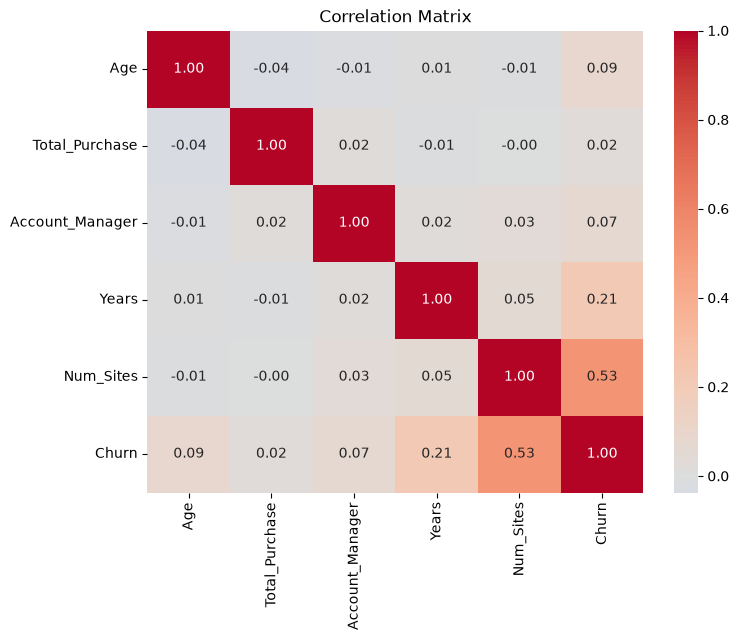

In [8]:
numeric_cols = ['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites', 'Churn']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [9]:
t_stat, p_value = stats.ttest_ind(churned['Age'],retained['Age'])
print(f"Age: t={t_stat:.3f}, p={p_value:.4f}")

df.groupby('Churn')['Age'].mean()

Age: t=2.584, p=0.0099


Churn
0    41.581333
1    42.993333
Name: Age, dtype: float64

Feature Engineering

In [10]:
# Drop identifier columns
df_model = df.drop(columns=['Names','Company'])

In [11]:

#Check if location(State) is significant before dropping column
df_model['State'] = df['Location'].str.extract(r',\s*([A-Z]{2})\s+\d{5}')
df_model['State'].value_counts()

State
OK    22
WV    18
TN    18
SC    18
AR    17
MN    17
ME    17
KY    17
ND    17
LA    17
AL    17
ID    17
AK    16
MH    16
FM    16
VA    16
PR    15
WI    15
MT    15
MI    15
DC    15
NH    15
WA    15
RI    14
MA    14
AZ    14
NV    14
IL    14
UT    14
GU    14
TX    14
IA    13
HI    13
NJ    13
VI    13
GA    13
NM    13
SD    13
NE    12
CT    12
DE    11
CO    11
AS    11
MS    11
KS    11
PW    11
NC    11
MP    11
OH    10
NY    10
IN    10
OR    10
CA     9
MD     9
VT     9
MO     8
FL     8
WY     7
PA     7
Name: count, dtype: int64

Counts by State too thin - overfitting is a concern. Mapping by Region instead and exploring significance of location

In [12]:
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}
df_model['Region'] = df_model['State'].map(region_map)
df_model['Region'].value_counts()

Region
South        252
West         168
Midwest      155
Northeast    111
Name: count, dtype: int64

In [13]:
df_model[df_model['Region'].isna()]['State'].value_counts()

State
MH    16
FM    16
PR    15
GU    14
VI    13
AS    11
PW    11
MP    11
Name: count, dtype: int64

In [14]:
# Mapping unmapped States 
df_model['Region'] = df_model['Region'].fillna('Territories')
df_model['Region'].value_counts()

Region
South          252
Territories    214
West           168
Midwest        155
Northeast      111
Name: count, dtype: int64

In [15]:
# Drop Location and State columns
df_model = df_model.drop(columns=['State', 'Location'])

In [16]:
# Extract Date features from "Onboard_date"
df_model['Onboard_year'] = df['Onboard_date'].dt.year
df_model['Onboard_month'] = df['Onboard_date'].dt.month
df_model = df_model.drop(columns=['Onboard_date'])

In [17]:
#Check shape of df
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              900 non-null    float64
 1   Total_Purchase   900 non-null    float64
 2   Account_Manager  900 non-null    int64  
 3   Years            900 non-null    float64
 4   Num_Sites        900 non-null    float64
 5   Churn            900 non-null    int64  
 6   Region           900 non-null    str    
 7   Onboard_year     900 non-null    int32  
 8   Onboard_month    900 non-null    int32  
dtypes: float64(4), int32(2), int64(2), str(1)
memory usage: 56.4 KB


In [18]:
#Encode Region
## One-hot coding, drop first set to true to avoid multicollinearity
df_model = pd.get_dummies(df_model,columns=['Region'], drop_first = True)
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 900 non-null    float64
 1   Total_Purchase      900 non-null    float64
 2   Account_Manager     900 non-null    int64  
 3   Years               900 non-null    float64
 4   Num_Sites           900 non-null    float64
 5   Churn               900 non-null    int64  
 6   Onboard_year        900 non-null    int32  
 7   Onboard_month       900 non-null    int32  
 8   Region_Northeast    900 non-null    bool   
 9   Region_South        900 non-null    bool   
 10  Region_Territories  900 non-null    bool   
 11  Region_West         900 non-null    bool   
dtypes: bool(4), float64(4), int32(2), int64(2)
memory usage: 52.9 KB


Divide dataset into training and testing

In [19]:
from sklearn.model_selection import train_test_split

x = df_model.drop(columns=['Churn'])
y = df_model['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42, stratify = y)

print(x_train.shape, x_test.shape)

(720, 11) (180, 11)


First baseline model - Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(random_state = 42)
model.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

Evaluate logistic regression model

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
y_pred = model.predict(x_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       150
           1       0.79      0.50      0.61        30

    accuracy                           0.89       180
   macro avg       0.85      0.74      0.78       180
weighted avg       0.89      0.89      0.88       180

[[146   4]
 [ 15  15]]


Test a weighted model

In [22]:
model_weighted = LogisticRegression(random_state=42, class_weight='balanced')
model_weighted.fit(x_train_scaled, y_train)
y_pred_weighted = model_weighted.predict(x_test_scaled)

print(classification_report(y_test, y_pred_weighted))
print(confusion_matrix(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.95      0.85      0.89       150
           1       0.50      0.77      0.61        30

    accuracy                           0.83       180
   macro avg       0.72      0.81      0.75       180
weighted avg       0.87      0.83      0.85       180

[[127  23]
 [  7  23]]


Explore decision threshold

In [23]:
y_proba = model_weighted.predict_proba(x_test_scaled)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold}: Precision={precision:.2f}, Recall={recall:.2f}")

Threshold 0.3: Precision=0.39, Recall=0.93
Threshold 0.4: Precision=0.44, Recall=0.93
Threshold 0.5: Precision=0.50, Recall=0.77
Threshold 0.6: Precision=0.56, Recall=0.73
Threshold 0.7: Precision=0.66, Recall=0.70
